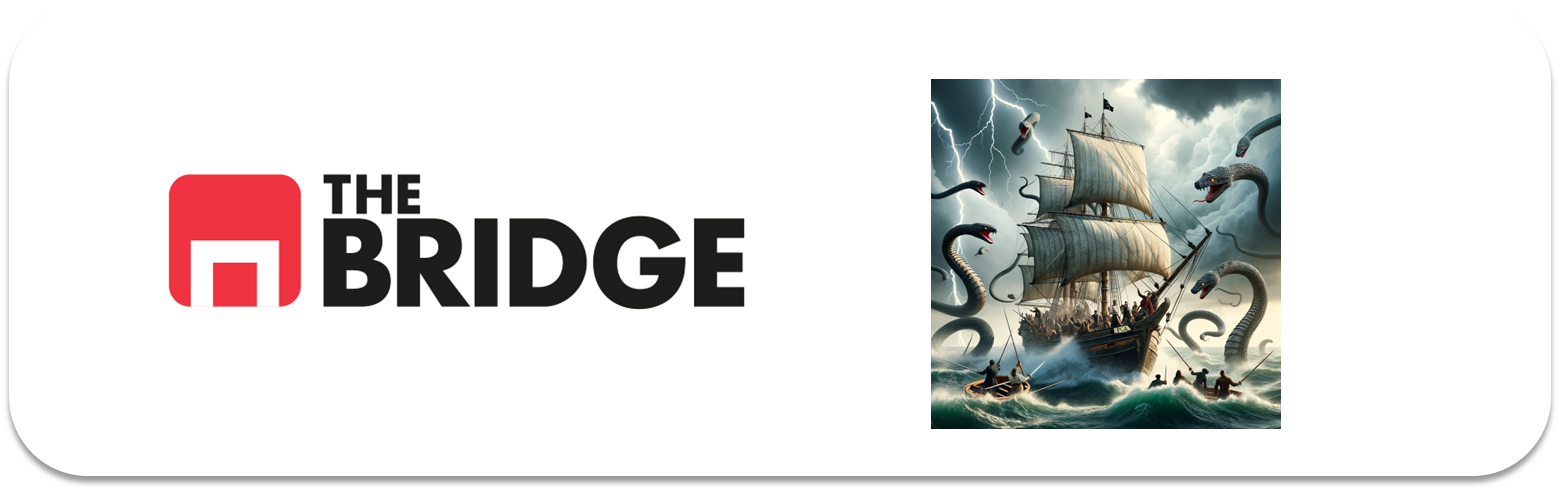

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


In [2]:
df = pd.read_csv("data/credit_npo.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [4]:
# Eliminar filas con nulos
df = df.dropna()

<Axes: >

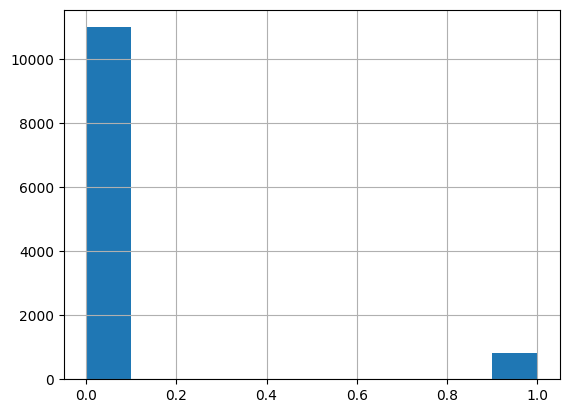

In [5]:
# Variable objetivo
df["SeriousDlqin2yrs"].hist()

In [6]:
from sklearn.model_selection import train_test_split

TARGET = 'SeriousDlqin2yrs'  # ← Cambia esto por el nombre de tu columna objetivo

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y         # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 9452 filas  (80 %)
Test:  2364 filas  (20 %)


In [7]:
def describe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un resumen estadístico descriptivo de un DataFrame.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.

    Retorna:
        pd.DataFrame: DataFrame con una fila por columna del input y las
        siguientes columnas: 'tipo', 'porcentaje_nulos', 'valores_unicos',
        'porcentaje_cardinalidad'.
        Retorna None si el input no es un DataFrame válido.
    """
    
    # Comprobación de que si es un DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None

    # Crear el DataFrame resultado
    resultado = pd.DataFrame(index=df.columns)

    # Tipo de dato
    resultado["tipo"] = df.dtypes.astype(str)

    # Porcentaje de nulos
    resultado["porcentaje_nulos"] = (df.isna().mean() * 100).round(2)

    # Valores únicos
    resultado["valores_unicos"] = df.nunique()

    # Porcentaje de cardinalidad
    resultado["porcentaje_cardinalidad"] = ((df.nunique() / len(df)) * 100).round(2)


    return resultado

In [8]:
describe_df(X_train)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
RevolvingUtilizationOfUnsecuredLines,float64,0.0,8253,87.31
age,int64,0.0,78,0.83
NumberOfTime30-59DaysPastDueNotWorse,int64,0.0,10,0.11
DebtRatio,float64,0.0,9200,97.33
MonthlyIncome,float64,0.0,3559,37.65
NumberOfOpenCreditLinesAndLoans,int64,0.0,41,0.43
NumberOfTimes90DaysLate,int64,0.0,12,0.13
NumberRealEstateLoansOrLines,int64,0.0,16,0.17
NumberOfTime60-89DaysPastDueNotWorse,int64,0.0,8,0.08
NumberOfDependents,float64,0.0,10,0.11


In [9]:
# valor desconocido (98)
X_train["NumberOfTime60-89DaysPastDueNotWorse"] = (
    X_train["NumberOfTime60-89DaysPastDueNotWorse"]
    .replace({98: "Unknown"})
)
X_test["NumberOfTime60-89DaysPastDueNotWorse"] = (
    X_test["NumberOfTime60-89DaysPastDueNotWorse"]
    .replace({98: "Unknown"})
)

In [10]:
# valor desconocido (98)
X_train["NumberOfTime30-59DaysPastDueNotWorse"] = (
    X_train["NumberOfTime30-59DaysPastDueNotWorse"]
    .replace({98: "Unknown"})
)
X_test["NumberOfTime30-59DaysPastDueNotWorse"] = (
    X_test["NumberOfTime30-59DaysPastDueNotWorse"]
    .replace({98: "Unknown"})
)

In [11]:
# Number of Dependents está en float y la pasamos a int para que sea una categórica
X_train["NumberOfDependents"] = X_train["NumberOfDependents"].astype(int)
X_test["NumberOfDependents"] = X_test["NumberOfDependents"].astype(int)

In [12]:
features_num = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberOfTimes90DaysLate",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents"
]


features_cat = ["NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfDependents"]

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 

    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.

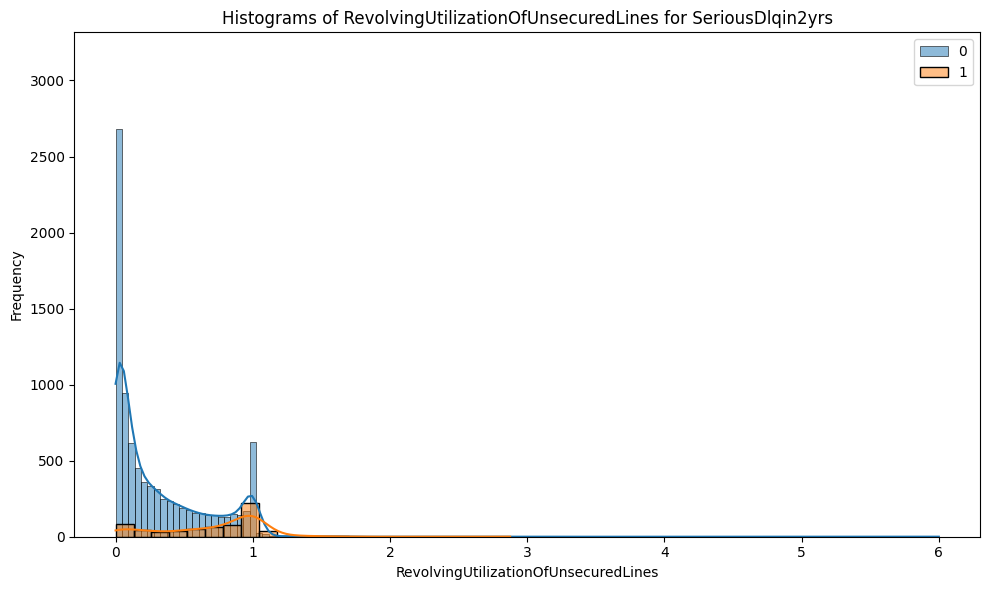

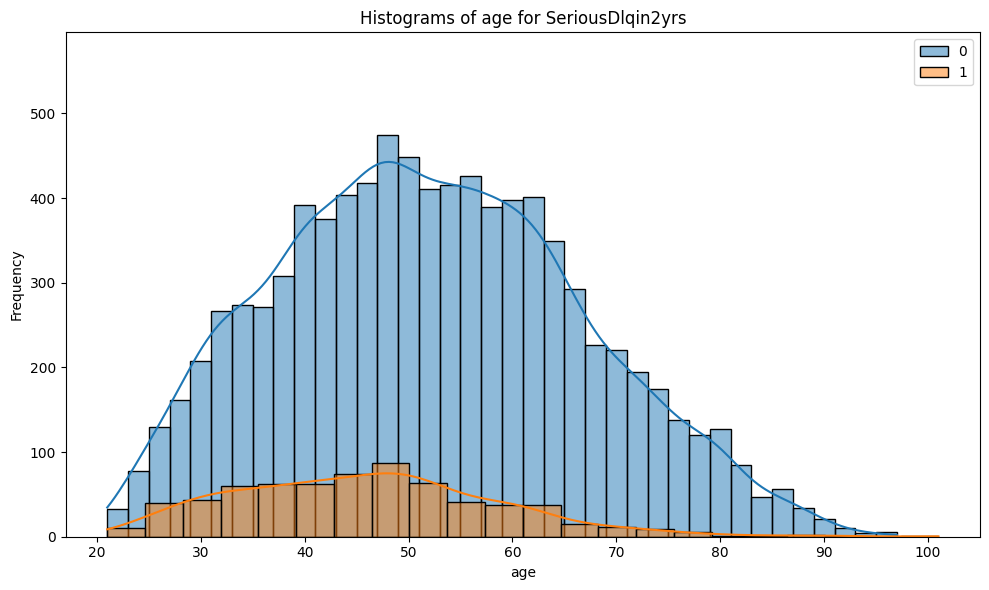

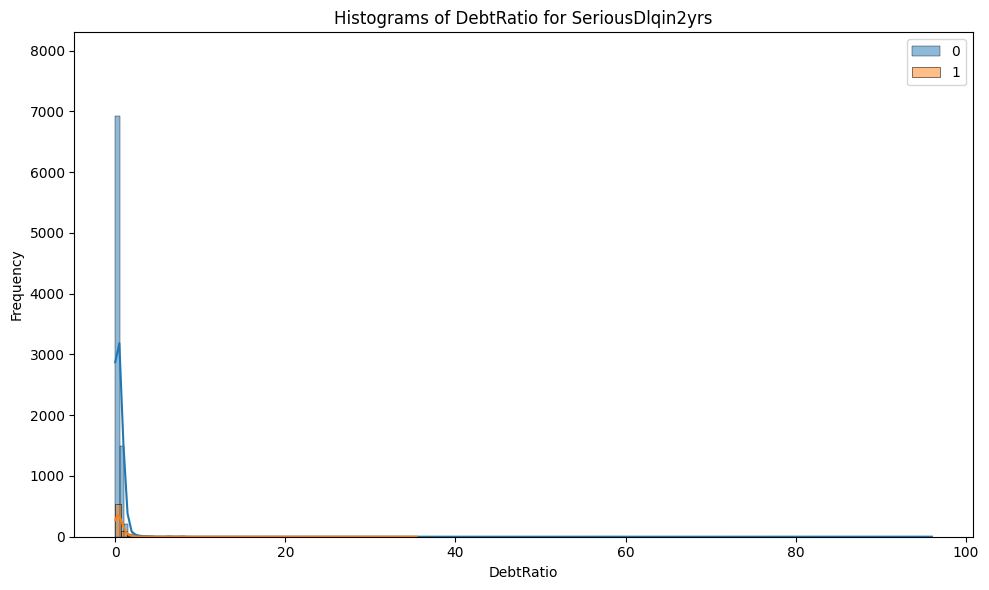

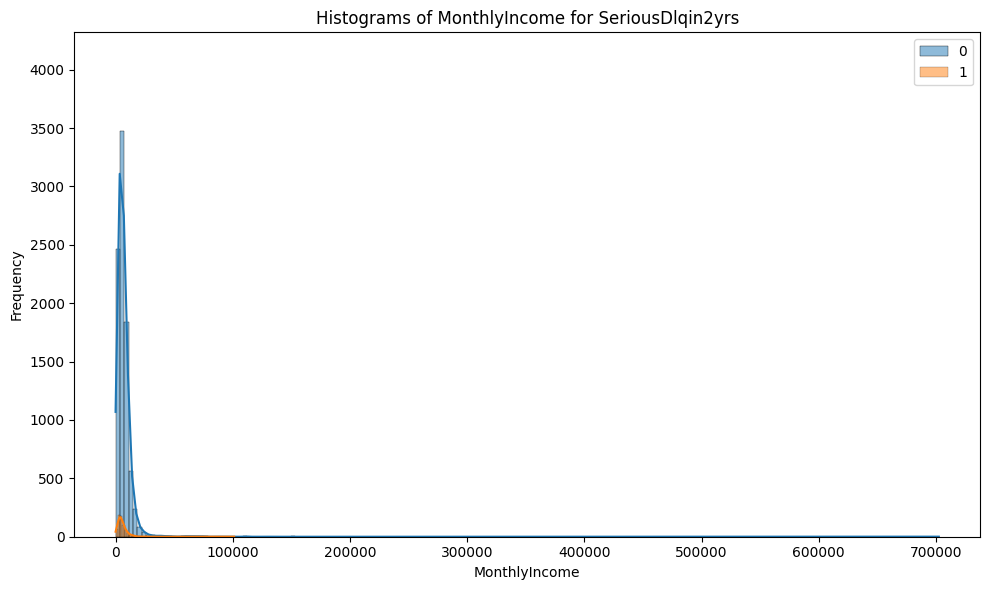

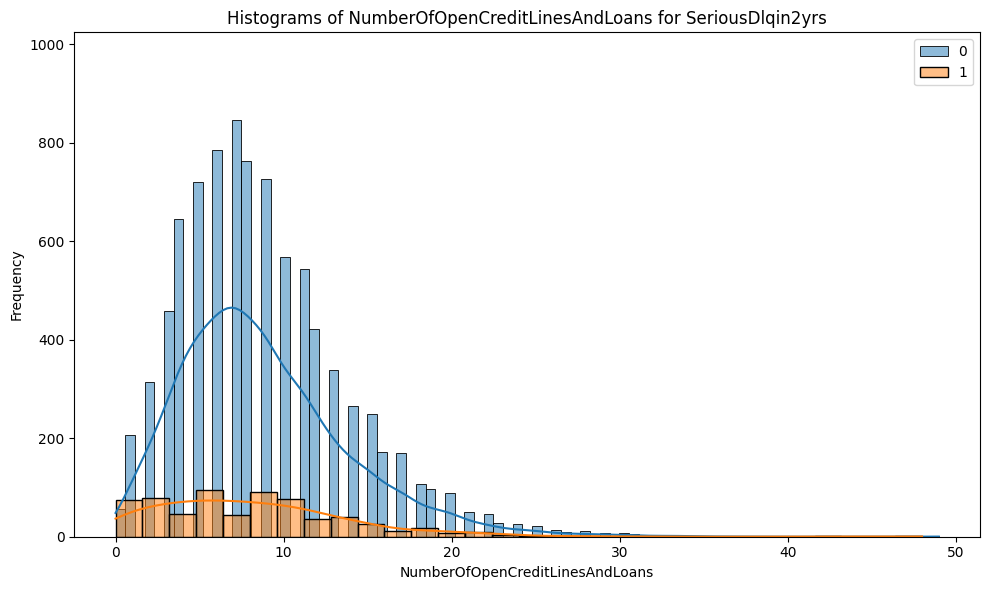

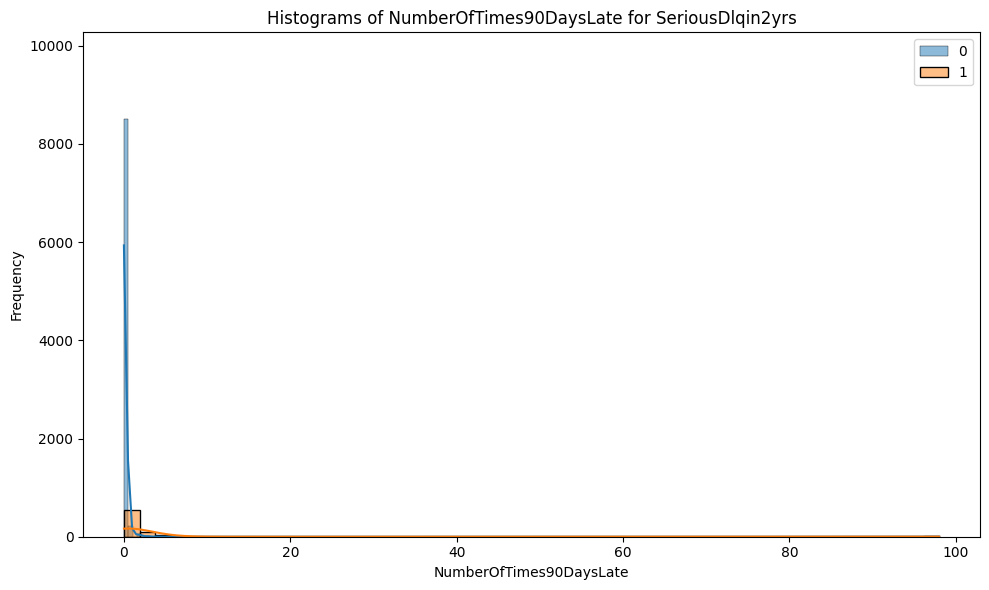

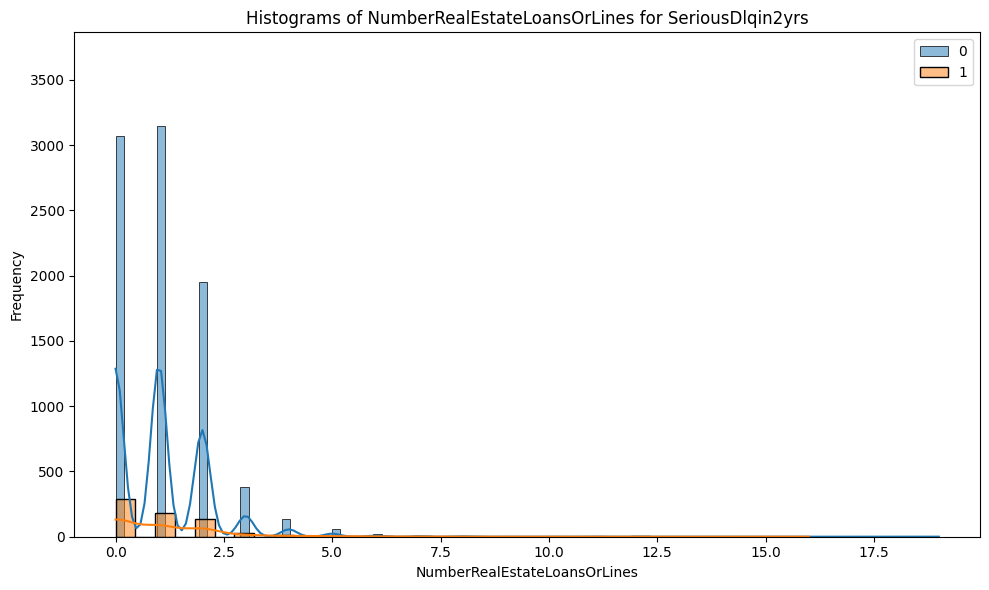

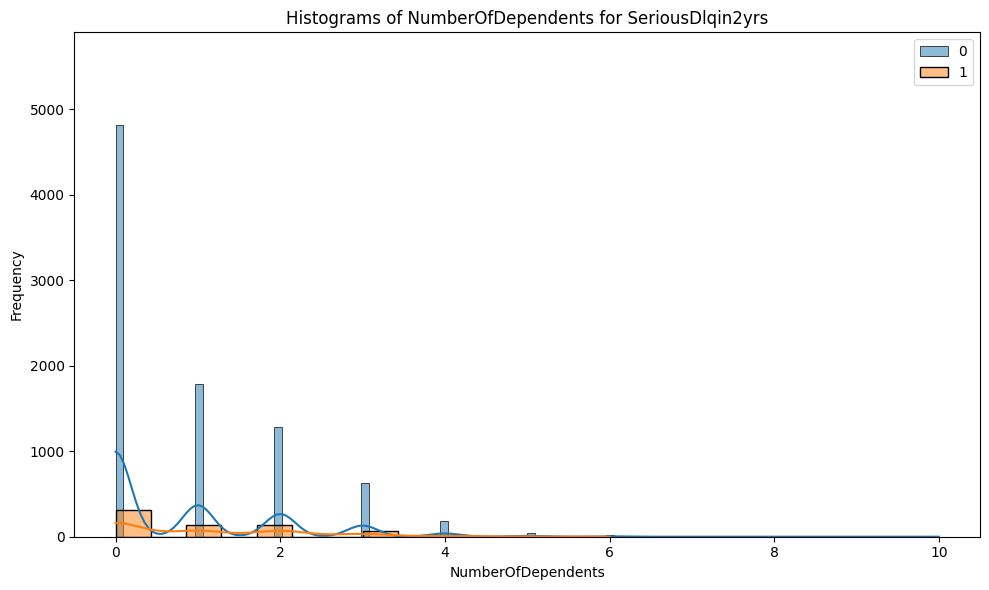

In [13]:
from bootcampviztools import plot_grouped_histograms

df_train = X_train.copy()
df_train[TARGET] = y_train

for col in features_num:
    plot_grouped_histograms(df_train, cat_col=TARGET, num_col=col)


In [14]:
# target categórica - features numéricas, metodo estadísitico ANOVA

from scipy.stats import f_oneway

anova_results = {}

for col in features_num:
    grupo_0 = X_train[y_train == 0][col]
    grupo_1 = X_train[y_train == 1][col]
    
    f_stat, p_value = f_oneway(grupo_0, grupo_1)
    anova_results[col] = p_value

anova_results


{'RevolvingUtilizationOfUnsecuredLines': np.float64(1.1619033141025916e-166),
 'age': np.float64(1.0693542743108216e-24),
 'DebtRatio': np.float64(0.9931331620554807),
 'MonthlyIncome': np.float64(0.013351252034927678),
 'NumberOfOpenCreditLinesAndLoans': np.float64(0.0011189393790142985),
 'NumberOfTimes90DaysLate': np.float64(8.069865271657501e-38),
 'NumberRealEstateLoansOrLines': np.float64(0.5748360651692891),
 'NumberOfDependents': np.float64(7.338829741229398e-06)}

In [15]:
# Seleccionamos las features numerícas con p value menor a 0.05

features_num_selec_manual = [
    col for col, p in anova_results.items() if p < 0.05
]
features_num_selec_manual


['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberOfDependents']

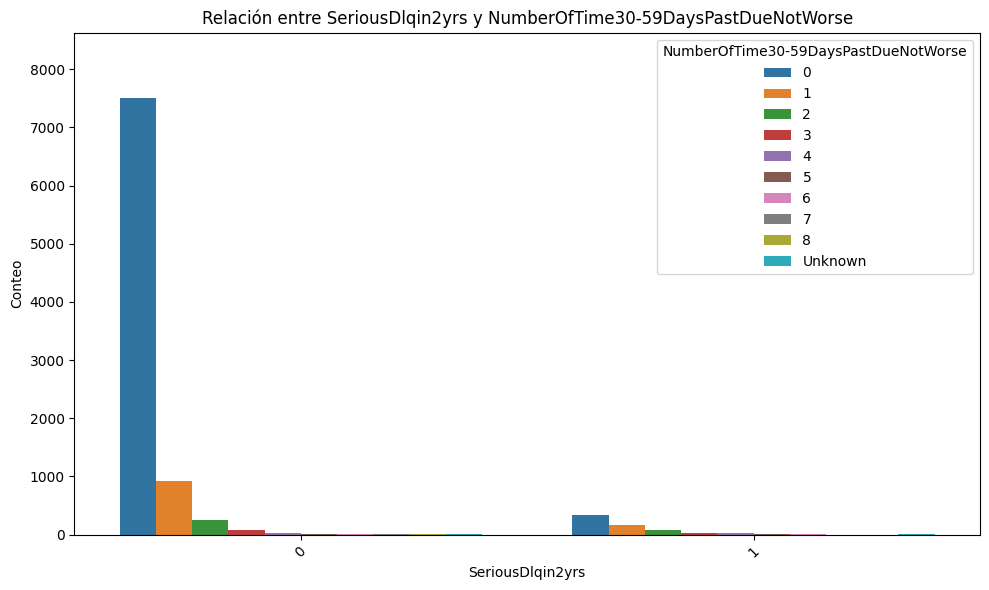

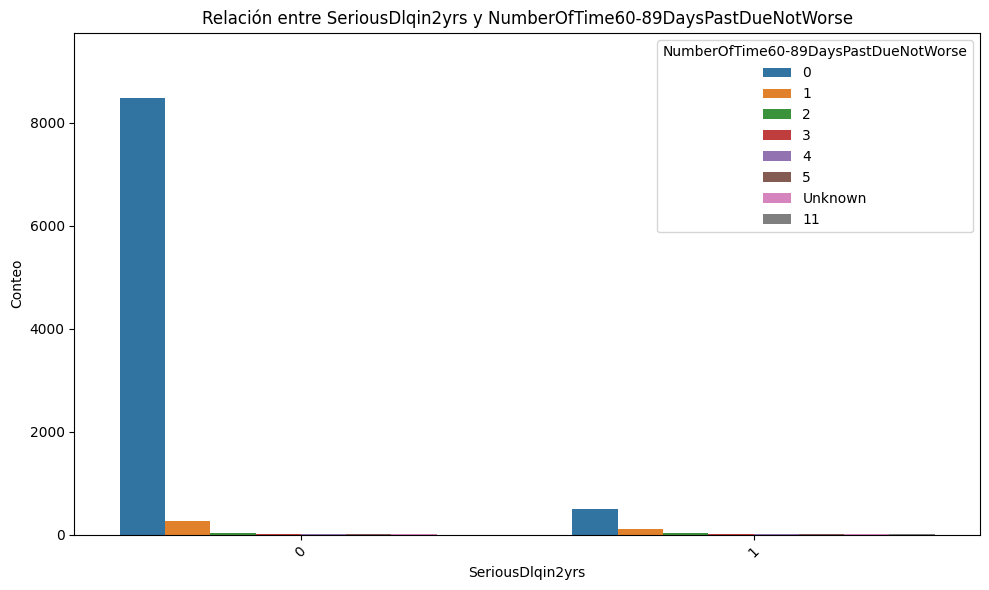

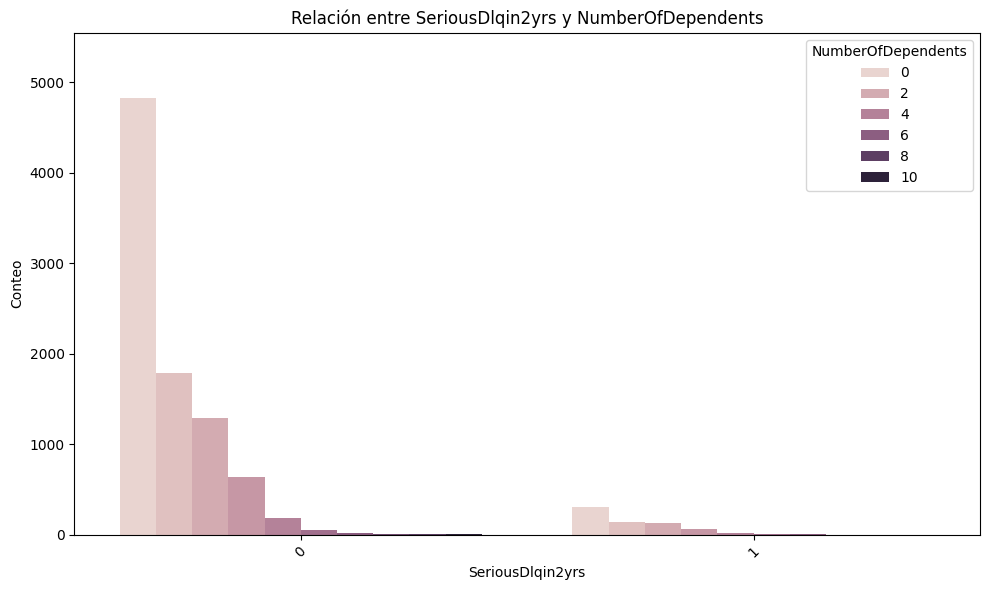

In [16]:
from bootcampviztools import plot_categorical_relationship

df_train = X_train.copy()
df_train[TARGET] = y_train

for col in features_cat:
    plot_categorical_relationship(df_train, cat_col1=TARGET, cat_col2=col)


In [17]:
# Target categórica - features categoricas
from scipy.stats import chi2_contingency

df_train = X_train.copy()
df_train[TARGET] = y_train
df_train = df_train.dropna()

chi2_results = {}

for col in features_cat:
    tabla = pd.crosstab(df_train[col], df_train[TARGET])
    chi2, p, dof, expected = chi2_contingency(tabla)
    chi2_results[col] = p

chi2_results

{'NumberOfTime30-59DaysPastDueNotWorse': np.float64(4.364033298125619e-144),
 'NumberOfTime60-89DaysPastDueNotWorse': np.float64(2.518085618919327e-154),
 'NumberOfDependents': np.float64(0.0017833087435681996)}

In [18]:
features_cat_selec_manual = [
    col for col, p in chi2_results.items() if p < 0.05
]
features_cat_selec_manual


['NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 


In [19]:
# Método SelectKBest y ANOVA

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# 1. Modelo base
rf_selector = RandomForestClassifier(random_state=42)

# 2. SelectFromModel con umbral = mediana
selector_model = SelectFromModel(estimator=rf_selector, threshold="median")

# 3. Ajustar el selector
selector_model.fit(X_train[features_num], y_train)

# 4. Extraer las features seleccionadas
features_num_selec_selectkbest = X_train[features_num].columns[selector_model.get_support()].tolist()
features_num_selec_selectkbest


['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']

In [20]:
# Selección features mediante Mutual Information

from sklearn.metrics import mutual_info_score

df_mi = df.dropna()
for col in features_cat:
    print(f"MI({col};{TARGET}):", mutual_info_score(df_mi[col],df_mi[TARGET]))

MI(NumberOfTime30-59DaysPastDueNotWorse;SeriousDlqin2yrs): 0.02401843701459362
MI(NumberOfTime60-89DaysPastDueNotWorse;SeriousDlqin2yrs): 0.01984855135498301
MI(NumberOfDependents;SeriousDlqin2yrs): 0.001269583894233336


In [21]:
mi_results = {
    "NumberOfTime30-59DaysPastDueNotWorse": 0.02401843701459362,
    "NumberOfTime60-89DaysPastDueNotWorse": 0.01984855135498301,
    "NumberOfDependents": 0.001269583894233336
}

features_cat_selec_mutualinformation = [
    col for col, mi in mi_results.items() if mi > 0.01
]
features_cat_selec_mutualinformation

['NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse']

    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)

    4. Selección de las mejores features empleando RFE.

In [22]:
# ============================================================
# 4. Selección de las mejores features empleando RFE
# ============================================================

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Modelo base
lr_model = LogisticRegression(max_iter=1000)

# RFE seleccionando 5 features numéricas
rfe_selector = RFE(estimator=lr_model, n_features_to_select=5)

# Ajuste del selector
rfe_selector.fit(X_train[features_num], y_train)

# Features seleccionadas
features_rfe = X_train[features_num].columns[rfe_selector.get_support()].tolist()
features_rfe


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['RevolvingUtilizationOfUnsecuredLines',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfDependents']

    5. Selección de las mejores features empleando SFS.

In [23]:
# ============================================================
# 5. Selección de las mejores features empleando SFS
# ============================================================

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Modelo base
lr_model = LogisticRegression(max_iter=1000)

# SFS seleccionando 5 features numéricas
sfs_selector = SequentialFeatureSelector(
    estimator=lr_model,
    n_features_to_select=5,
    direction='forward'
)

# Ajuste del selector
sfs_selector.fit(X_train[features_num], y_train)

# Features seleccionadas
features_sfs = X_train[features_num].columns[sfs_selector.get_support()].tolist()
features_sfs


['DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberOfDependents']

    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

In [24]:
# ============================================================
# 6. Selección de las mejores features mediante Hard Voting
# ============================================================

import pandas as pd

# Listas obtenidas en los pasos 1 a 5
listas_features = {
    "ANOVA_manual_num": features_num_selec_manual,
    "Chi2_manual_cat": features_cat_selec_manual,
    "SelectKBest_num": features_num_selec_selectkbest,
    "MutualInfo_cat": features_cat_selec_mutualinformation,
    "RFE_num": features_rfe,
    "SFS_num": features_sfs
}

# Convertimos a una sola lista larga
todas = []
for metodo, lista in listas_features.items():
    todas.extend(lista)

# Contamos votos por feature
votos = pd.Series(todas).value_counts()

# Mostramos el ranking completo
print("Ranking de features por número de votos:")
print(votos)

# Selección final: top 6 features más votadas
features_finales = votos.head(6).index.tolist()
features_finales


Ranking de features por número de votos:
NumberOfDependents                      4
RevolvingUtilizationOfUnsecuredLines    3
MonthlyIncome                           3
NumberOfOpenCreditLinesAndLoans         3
NumberOfTimes90DaysLate                 3
age                                     2
NumberOfTime30-59DaysPastDueNotWorse    2
NumberOfTime60-89DaysPastDueNotWorse    2
DebtRatio                               2
NumberRealEstateLoansOrLines            1
Name: count, dtype: int64


['NumberOfDependents',
 'RevolvingUtilizationOfUnsecuredLines',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'age']

In [25]:
features_finales = [
    'RevolvingUtilizationOfUnsecuredLines',
    'MonthlyIncome',
    'NumberOfDependents',
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate'
]

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

In [26]:
X_train.describe()

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfDependents
count,9452.000000,9452.000000,9452.000000,9452.000000,9452.000000,9452.000000,9452.000000,9452.000000
mean,0.336250,51.473445,0.507346,6927.238785,8.750529,0.194985,1.067605,0.855269
std,0.367448,14.582557,2.711252,12765.288137,5.118403,3.218289,1.155821,1.150417
min,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.034696,41.000000,0.144282,3498.750000,5.000000,0.000000,0.000000,0.000000
50%,0.177681,51.000000,0.295119,5450.000000,8.000000,0.000000,1.000000,0.000000
75%,0.587535,62.000000,0.478447,8333.000000,11.000000,0.000000,2.000000,2.000000
max,6.000000,101.000000,96.000000,702500.000000,49.000000,98.000000,19.000000,10.000000


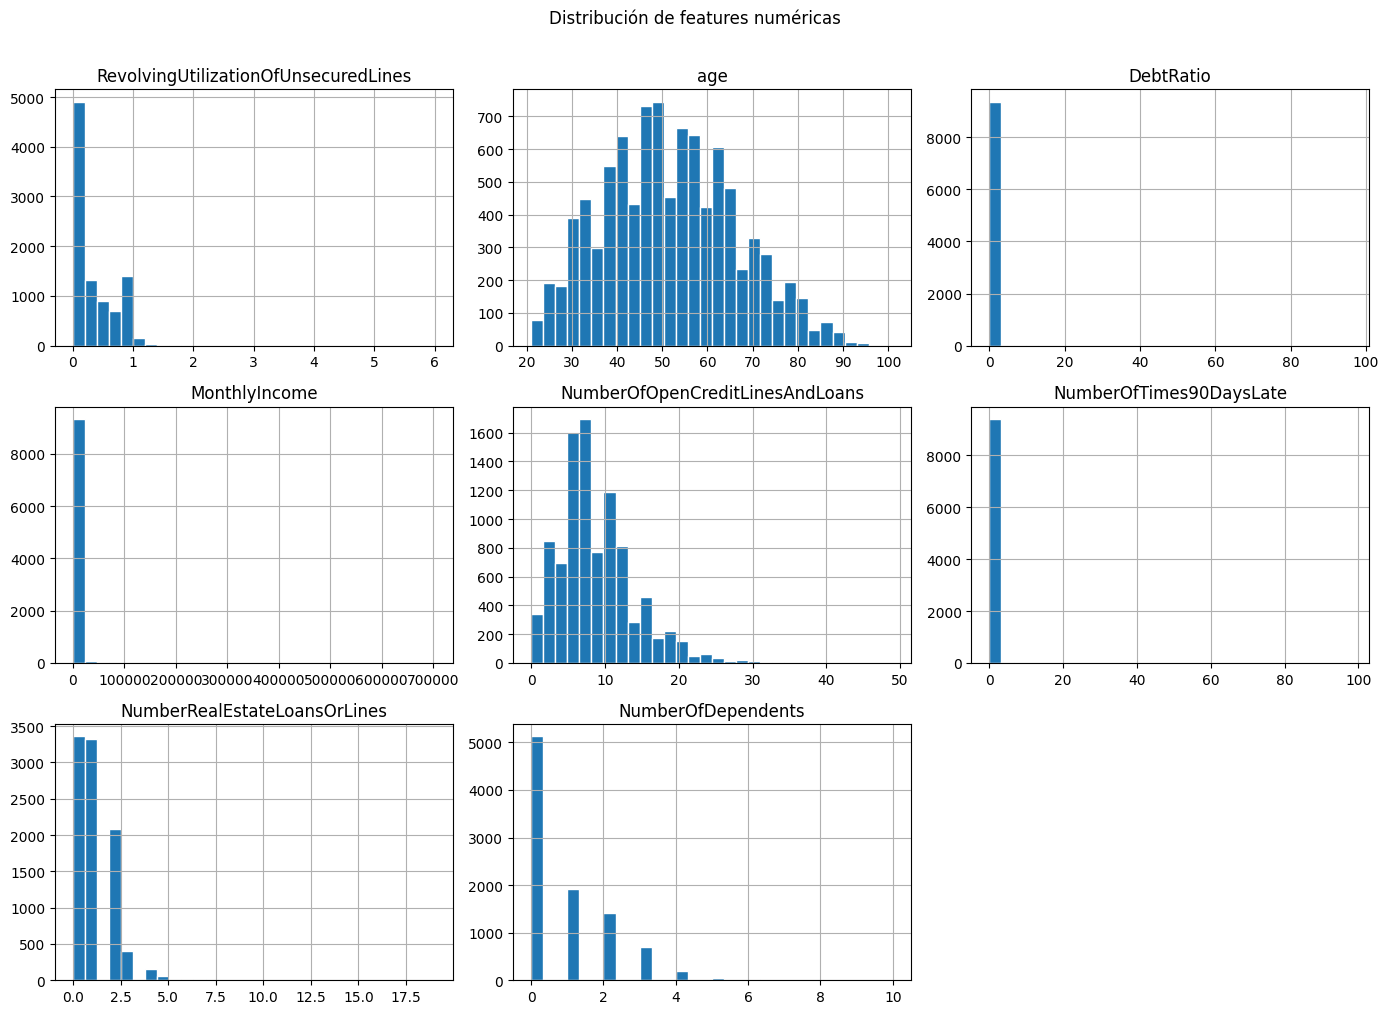

Skewness por feature:
MonthlyIncome                           34.143968
NumberOfTimes90DaysLate                 29.728308
DebtRatio                               23.926351
NumberRealEstateLoansOrLines             2.680958
RevolvingUtilizationOfUnsecuredLines     1.597593
NumberOfDependents                       1.398792
NumberOfOpenCreditLinesAndLoans          1.125697
age                                      0.248224


In [27]:
import matplotlib.pyplot as plt

X_train.select_dtypes('number').hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Skewness de cada feature numérica
skew = X_train.select_dtypes('number').skew().sort_values(key=abs, ascending=False)
print("Skewness por feature:")
print(skew.to_string())

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train_trans = X_train.copy()
X_test_trans = X_test.copy()


features_to_log = [
    'MonthlyIncome',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'NumberRealEstateLoansOrLines',
    'RevolvingUtilizationOfUnsecuredLines',
    'NumberOfDependents',
    'NumberOfOpenCreditLinesAndLoans'
]

for col in features_to_log:
    X_train_trans[col] = np.log1p(X_train_trans[col])
    X_test_trans[col] = np.log1p(X_test_trans[col])


scaler = StandardScaler()

X_train_trans[features_num] = scaler.fit_transform(X_train_trans[features_num])
X_test_trans[features_num] = scaler.transform(X_test_trans[features_num])

In [37]:
features_cat

for feature in features_cat:
    print(X_train[feature].value_counts())


NumberOfTime30-59DaysPastDueNotWorse
0          7840
1          1086
2           327
3           105
4            51
5            17
6            14
Unknown      10
7             1
8             1
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
0          8967
1           380
2            64
3            15
4            11
Unknown      10
5             4
11            1
Name: count, dtype: int64
NumberOfDependents
0     5130
1     1925
2     1421
3      695
4      204
5       53
6       21
10       1
7        1
8        1
Name: count, dtype: int64


In [40]:

cols_with_unknown = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents'
]

# 1. Convertir Unknown → NaN
for col in cols_with_unknown:
    X_train[col] = X_train[col].replace("Unknown", np.nan)
    X_test[col] = X_test[col].replace("Unknown", np.nan)

# 2. Convertir a numérico
for col in cols_with_unknown:
    X_train[col] = pd.to_numeric(X_train[col])
    X_test[col] = pd.to_numeric(X_test[col])

# 3. Imputación train y test
for col in cols_with_unknown:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)


In [42]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd


modelos = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=False
    )
}

# Tus 6 listas de features
listas_features = {
    "ANOVA_manual_num": features_num_selec_manual,
    "Chi2_manual_cat": features_cat_selec_manual,
    "SelectKBest_num": features_num_selec_selectkbest,
    "MutualInfo_cat": features_cat_selec_mutualinformation,
    "RFE_num": features_rfe,
    "SFS_num": features_sfs
}

# Validación cruzada con recall
resultados = []

for nombre_lista, lista in listas_features.items():
    X_train_sub = X_train[lista]

    for nombre_modelo, modelo in modelos.items():
        scores = cross_val_score(modelo, X_train_sub, y_train, cv=5, scoring='recall')
        resultados.append({
            "Modelo": nombre_modelo,
            "Lista_features": nombre_lista,
            "Recall_medio": scores.mean()
        })

df_resultados = pd.DataFrame(resultados).sort_values("Recall_medio", ascending=False)
df_resultados


c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:18:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:18:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:18:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Usuario\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:18:44] WARNING: 

,Modelo,Lista_features,Recall_medio
12,RandomForest,RFE_num,0.241023
13,XGBoost,RFE_num,0.228913
2,CatBoost,ANOVA_manual_num,0.225928
14,CatBoost,RFE_num,0.224402
1,XGBoost,ANOVA_manual_num,0.212326
0,RandomForest,ANOVA_manual_num,0.198838
15,RandomForest,SFS_num,0.177774
16,XGBoost,SFS_num,0.168672
17,CatBoost,SFS_num,0.164183
7,XGBoost,SelectKBest_num,0.078309


4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score

# 1. Selección final de features
X_train_final = X_train[features_rfe]
X_test_final = X_test[features_rfe]

# 2. Modelo final
rf_final = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_estimators=300,
    max_depth=None,
    min_samples_split=5
)

rf_final.fit(X_train_final, y_train)

# 3. Predicciones
y_pred = rf_final.predict(X_test_final)

# 4. Métricas
print("Recall clase 1:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Recall clase 1: 0.30120481927710846
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2198
           1       0.30      0.30      0.30       166

    accuracy                           0.90      2364
   macro avg       0.62      0.62      0.62      2364
weighted avg       0.90      0.90      0.90      2364

[[2079  119]
 [ 116   50]]


In [44]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]
}

rf_base = RandomForestClassifier(random_state=42)

grid_rf = GridSearchCV(
    rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_rf.fit(X_train[features_rfe], y_train)

print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Mejor recall CV:", grid_rf.best_score_)


Mejores hiperparámetros: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Mejor recall CV: 0.5361130097972203


In [45]:
rf_final = grid_rf.best_estimator_
rf_final.fit(X_train[features_rfe], y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [46]:
from sklearn.metrics import recall_score, classification_report, confusion_matrix

y_pred = rf_final.predict(X_test[features_rfe])

print("Recall clase 1:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Recall clase 1: 0.5602409638554217
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2198
           1       0.24      0.56      0.34       166

    accuracy                           0.84      2364
   macro avg       0.60      0.71      0.62      2364
weighted avg       0.91      0.84      0.87      2364

[[1904  294]
 [  73   93]]


### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.